In [17]:
#Names: Trevor Henderson, Alex Velasquez
#dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance

# Import necessary libraries for data manipulation, math, and plotting
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Load the dataset and remove missing values
df = pd.read_csv('insurance.csv')
df = df.dropna()

# Convert text columns to numbers so the model can process them
df['sex']    = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

print(df.head(20))

    age  sex     bmi  children  smoker  region      charges
0    19    0  27.900         0       1       3  16884.92400
1    18    1  33.770         1       0       2   1725.55230
2    28    1  33.000         3       0       2   4449.46200
3    33    1  22.705         0       0       1  21984.47061
4    32    1  28.880         0       0       1   3866.85520
5    31    0  25.740         0       0       2   3756.62160
6    46    0  33.440         1       0       2   8240.58960
7    37    0  27.740         3       0       1   7281.50560
8    37    1  29.830         2       0       0   6406.41070
9    60    0  25.840         0       0       1  28923.13692
10   25    1  26.220         0       0       0   2721.32080
11   62    0  26.290         0       1       2  27808.72510
12   23    1  34.400         0       0       3   1826.84300
13   56    0  39.820         0       0       2  11090.71780
14   27    1  42.130         0       1       2  39611.75770
15   19    1  24.600         1       0  

In [19]:
# X holds all input features, y is the target variable we want to predict
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1338, 6)
y shape: (1338,)


In [20]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing, random_state ensures consistent results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 1070
Testing samples:  268


In [21]:
from sklearn.linear_model import LinearRegression

# Train the model using the training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully')

Model trained successfully


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions and measure model accuracy
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'MAE:   ${mae:,.2f}')
print(f'MSE:   {mse:,.2f}')
print(f'R²:    {r2:.4f}')

MAE:   $4,186.51
MSE:   33,635,210.43
R²:    0.7833


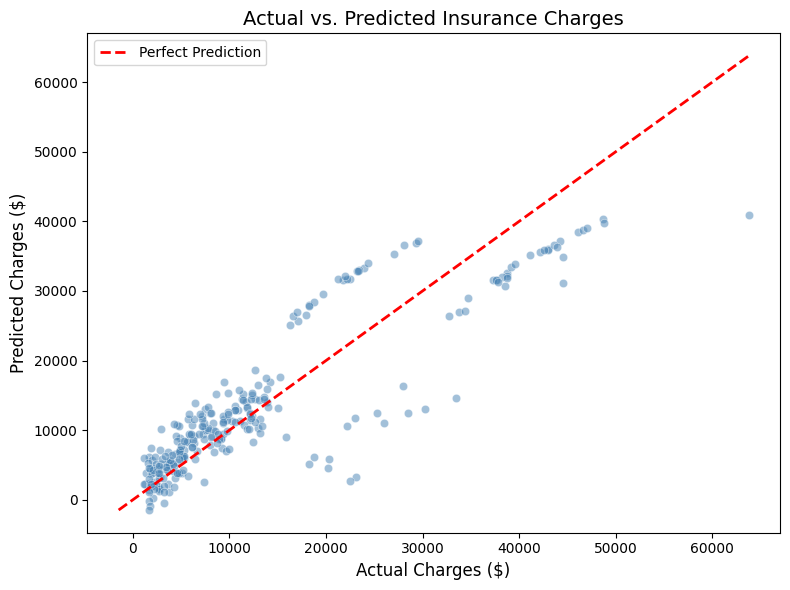


R² = 0.7833 means the model explains 78.3% of the variance in charges.


In [23]:
# Scatter plot of actual vs predicted charges — points near the red line mean accurate predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# Red dashed line represents perfect predictions
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.title('Actual vs. Predicted Insurance Charges', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nR² = {r2:.4f} means the model explains {r2*100:.1f}% of the variance in charges.')

In [24]:
# A multivariate linear regression model like this one would be used to help insurance companies predict charges
# based on multiple different variables. This allows them to more accurately predict charges so that they can make sure
# that they are providing fair value for service. This example specifically has shown that smokers
# will pay more on average for service than non smokers. The r^2 number of 0.78 means that this model will be 
# 78% accurate in determining charges based on these features.